In [2]:
print("Hello")

Hello


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

Step 1: Load Califonia Housing Datasets

In [4]:
data = fetch_california_housing(as_frame=True)
housing_df = data.frame

Step 2: Create histograms for numerical features

In [5]:
numerical_features = housing_df.select_dtypes(include=[np.number]).columns


Plot Histograms

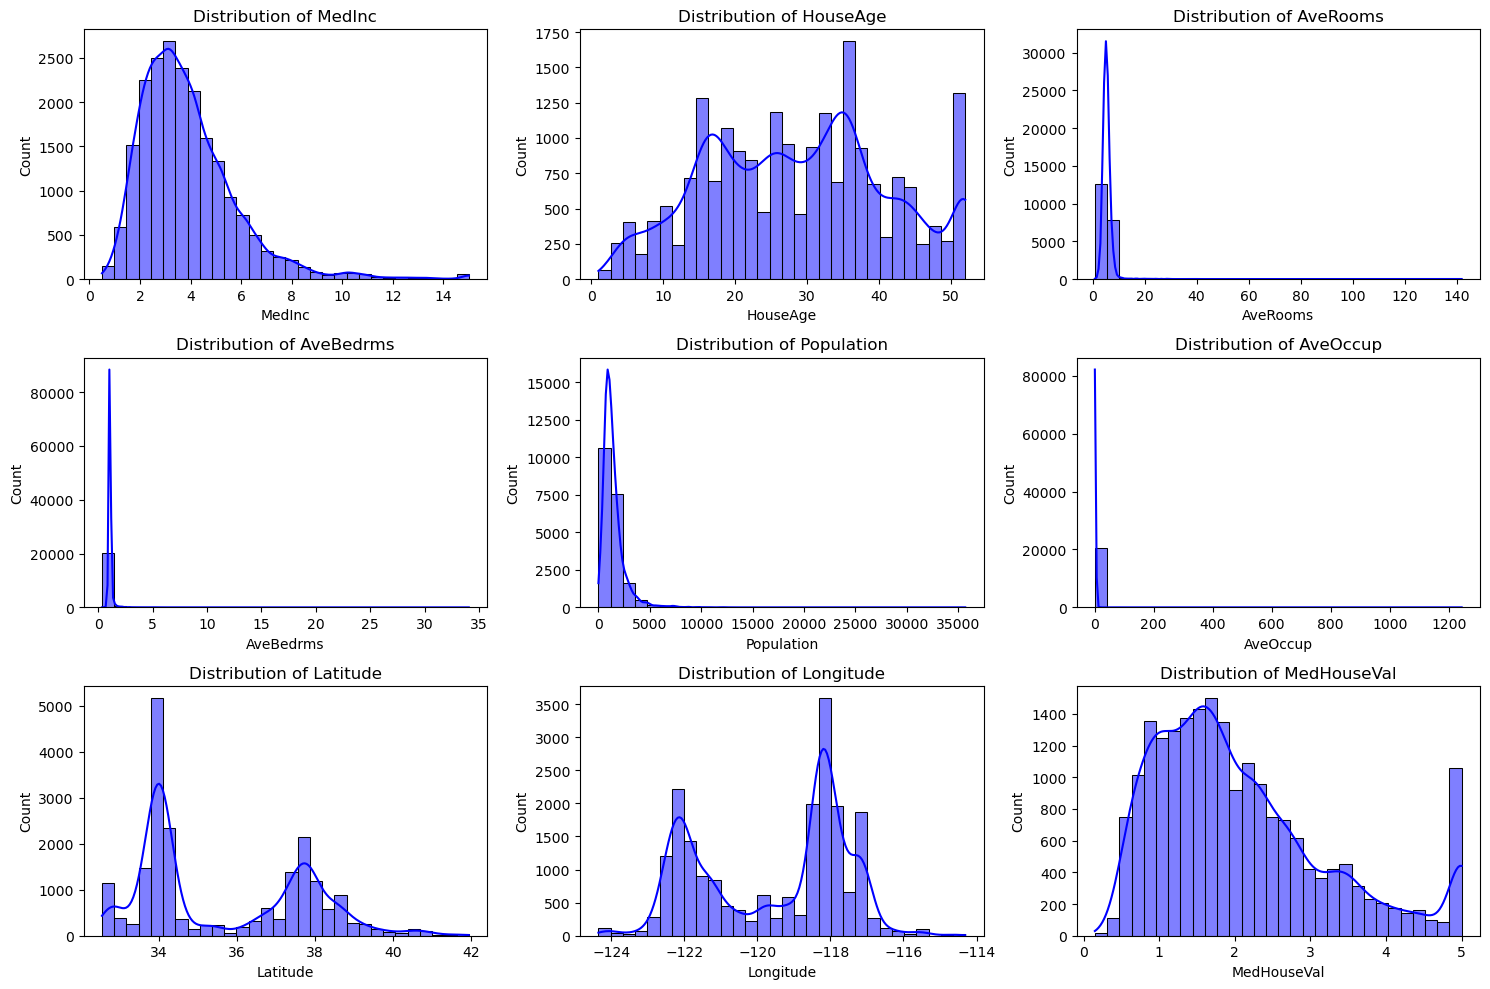

In [6]:
plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], color='blue', kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

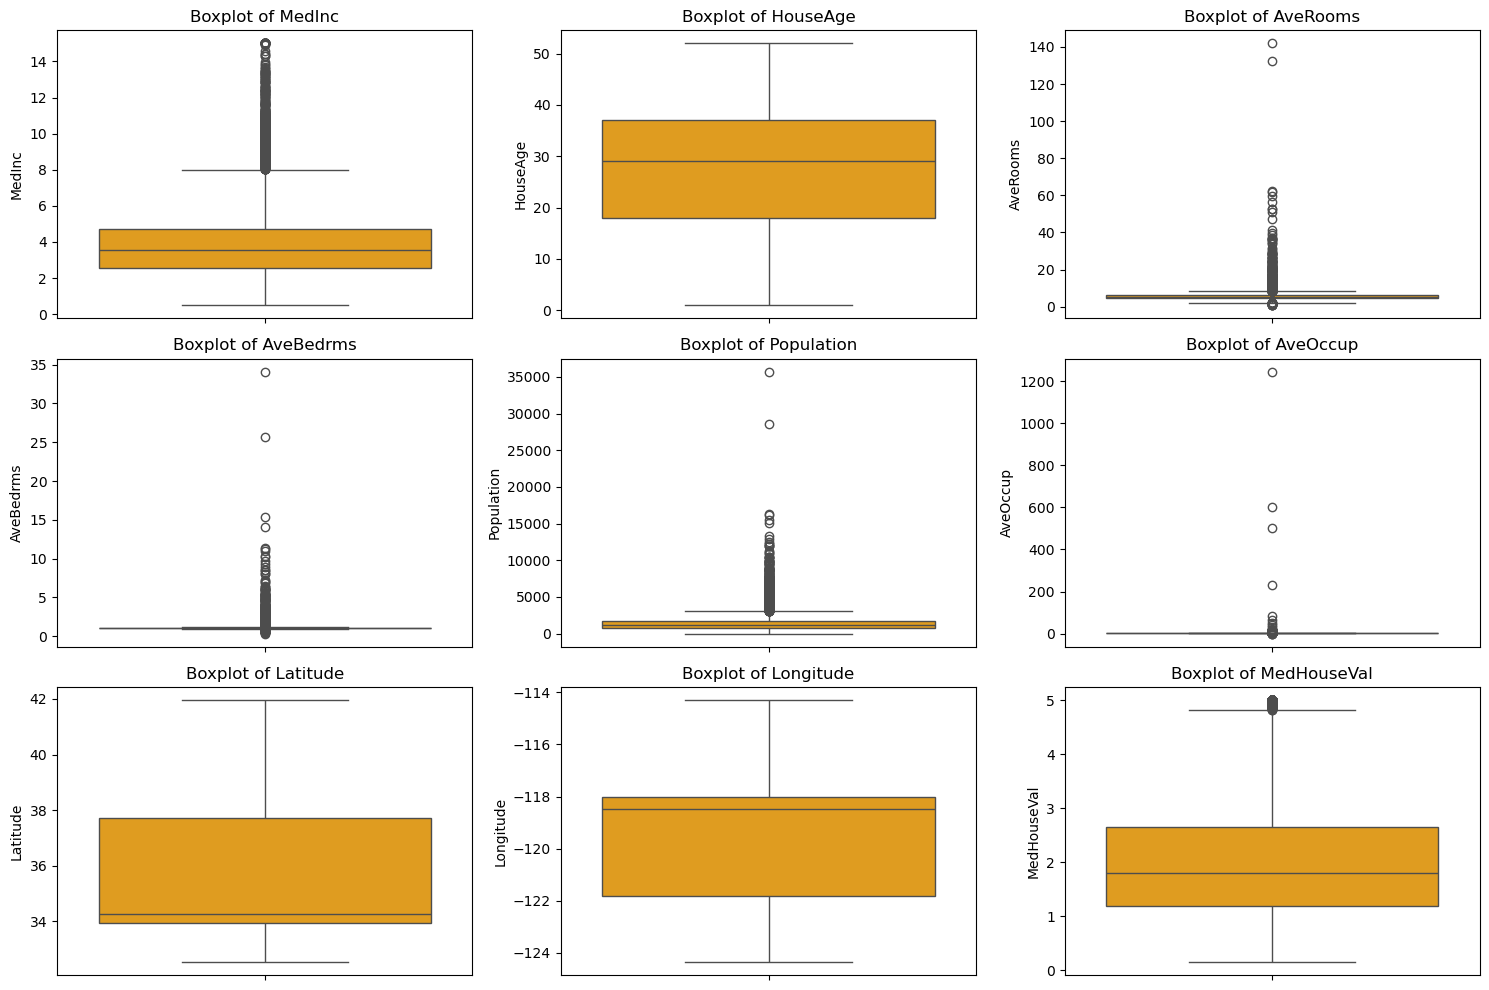

In [7]:
plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=housing_df[feature], color='orange')
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

Outlier Detection

In [8]:
outliers_summary = {}
for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = housing_df[(housing_df[feature] < lower_bound) | (housing_df[feature] > upper_bound)]
    outliers_summary[feature] = len(outliers)
    print(f'Feature: {feature}, Outliers: {len(outliers)}')

Feature: MedInc, Outliers: 681
Feature: HouseAge, Outliers: 0
Feature: AveRooms, Outliers: 511
Feature: AveBedrms, Outliers: 1424
Feature: Population, Outliers: 1196
Feature: AveOccup, Outliers: 711
Feature: Latitude, Outliers: 0
Feature: Longitude, Outliers: 0
Feature: MedHouseVal, Outliers: 1071


In [9]:
print("\nDataset Summary")
print(housing_df.describe())


Dataset Summary
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.69